In [2]:
# 한글깨짐 방지

import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')   # Ubuntu: sudo apt install fonts-nanum
plt.rc('axes', unicode_minus=False)

In [3]:
# 타이타닉 데이터 저장

import pandas as pd
TITANIC_URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(TITANIC_URL)
titanic_clean = titanic.copy()
titanic_clean['Age'] = titanic_clean['Age'].fillna(titanic_clean['Age'].median())

In [12]:
titanic_clean.head(50)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


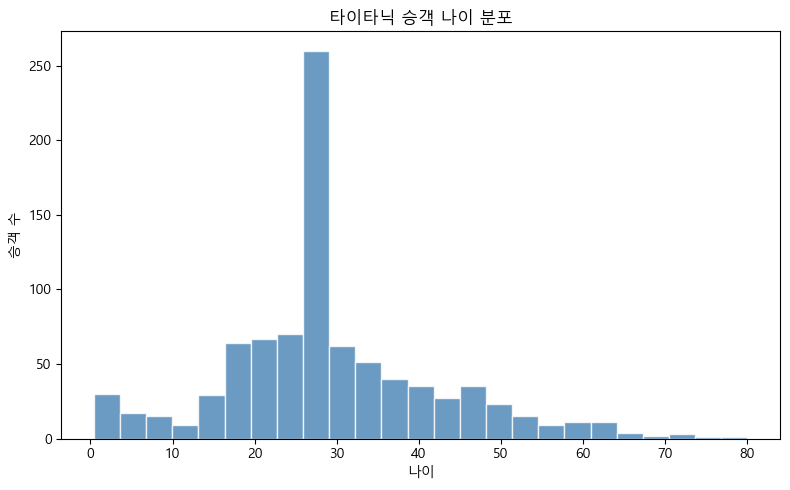

In [4]:
# 타이타닉 승객 나이 분포

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(titanic_clean['Age'],
        bins=25,
        color='steelblue',
        edgecolor='white',
        alpha=0.8)
ax.set_xlabel('나이')
ax.set_ylabel('승객 수')
ax.set_title('타이타닉 승객 나이 분포')
plt.tight_layout()
plt.show()

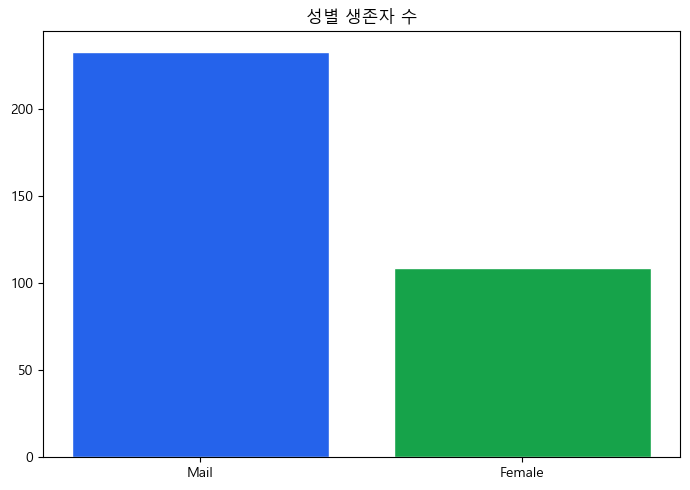

In [7]:
#타이타닉 성별 생존자 막대 그래프 표출

surv_class = titanic.groupby('Sex')['Survived'].sum()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(surv_class.index, surv_class.values,
       color=['#2563eb','#16a34a'], edgecolor='white')
ax.set_title('성별 생존자 수')
ax.set_xticks([0,1]); ax.set_xticklabels(['Mail','Female'])
plt.tight_layout(); plt.show()

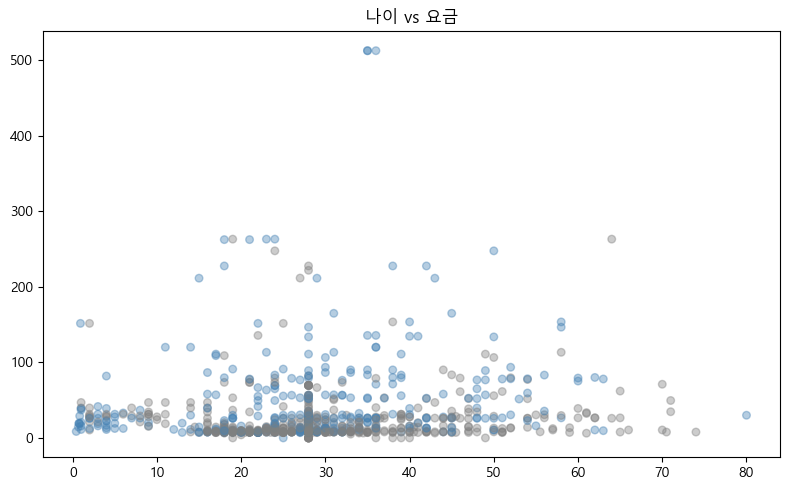

In [ ]:
# 나이 vs 요금 산점도 (생존여부에 따라 색상을 다르게 하여 구분)

colors = titanic_clean['Survived'].map(
    {0: 'gray', 1: 'steelblue'})

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(titanic_clean['Age'],
           titanic_clean['Fare'],
           c=colors, alpha=0.4, s=30)
ax.set_title('나이 vs 요금')
plt.tight_layout(); plt.show()

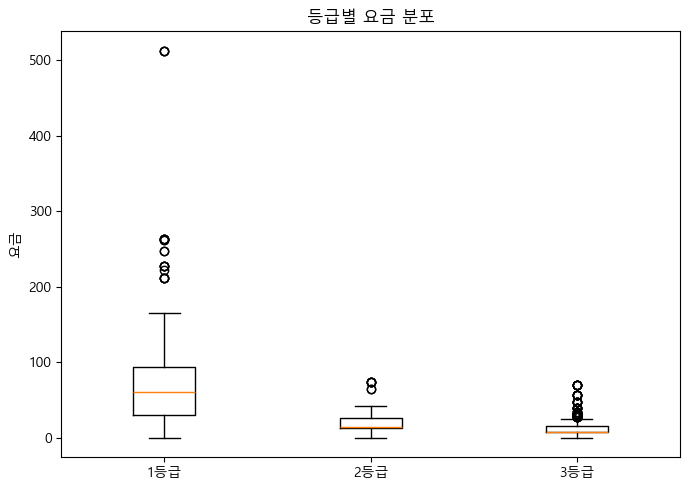

In [9]:
# 등급별 요금 박스플롯

data = [titanic[titanic['Pclass']==c]['Fare'].dropna()
        for c in [1,2,3]]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(data,
           tick_labels=['1등급','2등급','3등급'])
ax.set_ylabel('요금')
ax.set_title('등급별 요금 분포')
plt.tight_layout(); plt.show()

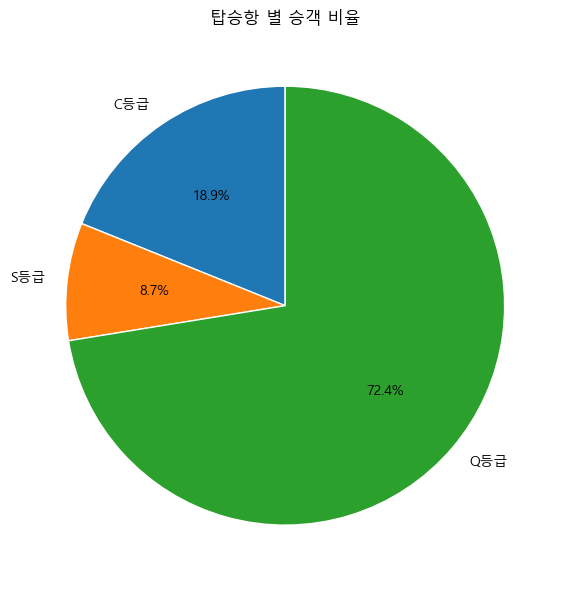

In [15]:
# 탑승항 (Embarked)별 승객 비율 파이차트

class_counts = titanic['Embarked'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(class_counts.values,
       labels=['C등급','S등급','Q등급'],
       autopct='%1.1f%%',
       startangle=90,
       wedgeprops=dict(edgecolor='white'))
ax.set_title('탑승항 별 승객 비율')
plt.tight_layout(); plt.show()

In [ ]:
# IMDB 데이터 

imdb = pd.read_csv('imdb_top_1000.csv')
# Released_Year에 'PG' 같은 비숫자 값이 있음 → 안전하게 변환
imdb['Released_Year'] = pd.to_numeric(imdb['Released_Year'], errors='coerce') 

In [17]:
# IMDB 평점 히스토그램

import plotly.express as px

fig = px.histogram(
    imdb, x='IMDB_Rating', nbins=20,
    marginal='box',            # 상단에 박스플롯 자동 추가
    title='IMDB 평점 분포',
    template='simple_white'
)
fig.show()

In [ ]:
# B7. 투표 수 vs 평점 scatter (hover_name=영화 제목)

fig = px.scatter(
    imdb,
    x='No_of_Votes',
    y='IMDB_Rating',
    hover_name='Series_Title',      # 굵게 표시
    hover_data=['Released_Year',
                'Genre'],
    title='투표 수 vs IMDB 평점',
    template='simple_white',
    opacity=0.6
)
fig.show()
fig.write_html('imdb_scatter.html')

In [ ]:
# 서울 아파트 데이터

sa = pd.read_csv('seoul_apartment.csv')
sa.shape   # (1260226, 13)

(1260226, 13)

In [24]:
sa.head(10)

,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),층,건축년도,도로명,구
0,1,서울특별시 종로구 사직동,9,9,0,광화문스페이스본(101동~105동),94.51,200811,3,63000,6,2008,사직로8길 4,종로구
1,2,서울특별시 종로구 사직동,9,9,0,광화문스페이스본(101동~105동),146.92,200810,10,97000,13,2008,사직로8길 4,종로구
2,3,서울특별시 종로구 사직동,9,9,0,광화문스페이스본(101동~105동),146.92,200810,7,100000,1,2008,사직로8길 4,종로구
3,4,서울특별시 종로구 사직동,9,9,0,광화문스페이스본(101동~105동),146.92,200810,1,95000,12,2008,사직로8길 4,종로구
4,5,서울특별시 종로구 사직동,9,9,0,광화문스페이스본(101동~105동),146.92,200809,26,95000,11,2008,사직로8길 4,종로구
5,6,서울특별시 종로구 사직동,9,9,0,광화문스페이스본(101동~105동),151.81,200809,22,92000,1,2008,사직로8길 4,종로구
6,7,서울특별시 종로구 사직동,9월 1일,9,1,광화문스페이스본(106동),144.52,200809,10,100540,13,2008,경희궁길 57,종로구
7,8,서울특별시 종로구 사직동,9,9,0,광화문스페이스본(101동~105동),94.51,200809,5,68000,9,2008,사직로8길 4,종로구
8,9,서울특별시 종로구 사직동,9,9,0,광화문스페이스본(101동~105동),108.55,200808,25,110000,14,2008,사직로8길 4,종로구
9,10,서울특별시 종로구 사직동,9,9,0,광화문스페이스본(101동~105동),70.80,200808,25,54000,3,2008,사직로8길 4,종로구


In [21]:
# 서울 아파트 plotly 시계열

monthly = (
    sa.groupby('계약년월')['거래금액(만원)']
    .mean()
    .reset_index()
)
monthly.columns = ['계약년월', '평균거래금액']

monthly['계약년월'] = monthly['계약년월'].astype(str)

fig = px.line(
    monthly,
    x='계약년월',
    y='평균거래금액',
    title='서울 아파트 월별 평균 거래가격',
    template='simple_white'
)
fig.update_xaxes(tickangle=45, nticks=24)
fig.show()

In [22]:
# 월별 거래 건수 - 막대그래프

cnt = (sa.groupby('계약년월')['NO']
       .count().reset_index())
cnt.columns = ['계약년월', '거래건수']
cnt['계약년월'] = cnt['계약년월'].astype(str)

fig = px.bar(cnt, x='계약년월', y='거래건수',
             template='simple_white')
fig.update_xaxes(tickangle=45, nticks=24)
fig.show()

In [23]:
# 구별 평균가격 - 수평막대

# '서울특별시 종로구 사직동' → '종로구'
sa['구'] = sa['시군구'].str.split().str[1]

gu = (sa.groupby('구')['거래금액(만원)']
      .mean()
      .sort_values(ascending=True)
      .reset_index())

fig = px.bar(
    gu, x='거래금액(만원)', y='구',
    orientation='h',
    color='거래금액(만원)',
    color_continuous_scale='Blues',
    title='서울 자치구별 평균 아파트 거래가격',
    template='simple_white'
)
fig.show()

In [36]:
# ================================
# 1. 최근 3년 필터링
# ================================
sa_recent = sa[(sa['계약년월'] >= '2022-01-01') & 
               (sa['계약년월'] <= '2024-12-31')]

print(f"최근 3년 데이터: {len(sa_recent)}건")

# ================================
# 2. 월별 평균 거래금액
# ================================
monthly = sa_recent.groupby('계약년월')['거래금액(만원)'].agg(
    평균가격='mean',
    최고가격='max',
    최저가격='min',
    거래건수='count'
).reset_index()

# ================================
# 3. 월별 추이 라인차트
# ================================
fig1 = px.line(
    monthly,
    x='계약년월',
    y='평균가격',
    title='최근 3년 (2022~2024) 월별 평균 거래금액 추이',
    markers=True,
    template='simple_white'
)
fig1.add_scatter(x=monthly['계약년월'], y=monthly['최고가격'],
                 mode='lines', name='최고가', line=dict(dash='dot', color='red'))
fig1.add_scatter(x=monthly['계약년월'], y=monthly['최저가격'],
                 mode='lines', name='최저가', line=dict(dash='dot', color='blue'))
fig1.show()
fig1.write_html('price_trend_3y.html')

# ================================
# 4. 면적대별 가격 추이
# ================================
sa_recent['면적대'] = pd.cut(sa_recent['전용면적(㎡)'],  # ← 수정
                             bins=[0, 60, 85, 135, 999],
                             labels=['소형(~60㎡)', '중형(~85㎡)', 
                                     '대형(~135㎡)', '초대형'])

area_monthly = sa_recent.groupby(
    ['계약년월', '면적대'], observed=True)['거래금액(만원)'].mean().reset_index()

fig2 = px.line(
    area_monthly,
    x='계약년월',
    y='거래금액(만원)',
    color='면적대',
    title='최근 3년 면적대별 거래금액 추이',
    markers=True,
    template='simple_white'
)
fig2.show()
fig2.write_html('price_trend_by_area_3y.html')

# ================================
# 5. 연도별 박스플롯
# ================================
sa_recent['연도'] = sa_recent['계약년월'].dt.year.astype(str)

fig3 = px.box(
    sa_recent,
    x='연도',
    y='거래금액(만원)',
    color='연도',
    title='2022 vs 2023 vs 2024 거래금액 분포 비교',
    template='simple_white'
)
fig3.show()
fig3.write_html('price_box_3y.html')

최근 3년 데이터: 62028건


In [29]:
# 데이터 현황 파악 먼저!
print(sa['계약년월'].astype(str).str[:4].value_counts().sort_index())
print(sa['거래금액(만원)'].dtype)
print(sa['전용면적(㎡)'].dtype)

계약년월
2006    111471
2007     53329
2008     48016
2009     73387
2010     44333
2011     54413
2012     40885
2013     67961
2014     85410
2015    119873
2016    110114
2017    104987
2018     81576
2019     74990
2020     84068
2021     43385
2022     12728
2023     35433
2024     13867
Name: count, dtype: int64
int64
float64


In [38]:
# 장르별 평점 (imdb)

print(imdb.columns.tolist())
imdb.head(10)

['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994.0,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972.0,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008.0,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974.0,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957.0,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"
5,https://m.media-amazon.com/images/M/MV5BNzA5ZD...,The Lord of the Rings: The Return of the King,2003.0,U,201 min,"Action, Adventure, Drama",8.9,Gandalf and Aragorn lead the World of Men agai...,94.0,Peter Jackson,Elijah Wood,Viggo Mortensen,Ian McKellen,Orlando Bloom,1642758,"377,845,905"
6,https://m.media-amazon.com/images/M/MV5BNGNhMD...,Pulp Fiction,1994.0,A,154 min,"Crime, Drama",8.9,"The lives of two mob hitmen, a boxer, a gangst...",94.0,Quentin Tarantino,John Travolta,Uma Thurman,Samuel L. Jackson,Bruce Willis,1826188,"107,928,762"
7,https://m.media-amazon.com/images/M/MV5BNDE4OT...,Schindler's List,1993.0,A,195 min,"Biography, Drama, History",8.9,"In German-occupied Poland during World War II,...",94.0,Steven Spielberg,Liam Neeson,Ralph Fiennes,Ben Kingsley,Caroline Goodall,1213505,"96,898,818"
8,https://m.media-amazon.com/images/M/MV5BMjAxMz...,Inception,2010.0,UA,148 min,"Action, Adventure, Sci-Fi",8.8,A thief who steals corporate secrets through t...,74.0,Christopher Nolan,Leonardo DiCaprio,Joseph Gordon-Levitt,Elliot Page,Ken Watanabe,2067042,"292,576,195"
9,https://m.media-amazon.com/images/M/MV5BMmEzNT...,Fight Club,1999.0,A,139 min,Drama,8.8,An insomniac office worker and a devil-may-car...,66.0,David Fincher,Brad Pitt,Edward Norton,Meat Loaf,Zach Grenier,1854740,"37,030,102"


In [39]:
# 장르별 평균 평점 var
imdb_genre = imdb.assign(
    Genre=imdb['Genre'].str.split(', ')
).explode('Genre')

print(imdb_genre['Genre'].value_counts())  # 장르 종류 확인

# ================================
# 2. 장르별 평균 평점 집계
# ================================
genre_rating = imdb_genre.groupby('Genre')['IMDB_Rating'].agg(
    평균평점='mean',
    작품수='count'
).reset_index().sort_values('평균평점', ascending=False)

# ================================
# 3. 바 차트
# ================================
fig = px.bar(
    genre_rating,
    x='Genre',
    y='평균평점',
    color='평균평점',
    color_continuous_scale='blues',
    text='평균평점',
    hover_data=['작품수'],      # 호버시 작품수 표시
    title='장르별 평균 IMDB 평점',
    template='simple_white'
)
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.update_layout(xaxis_tickangle=-45)
fig.show()
fig.write_html('genre_rating.html')

Genre
Drama        724
Comedy       233
Crime        209
Adventure    196
Action       189
Thriller     137
Romance      125
Biography    109
Mystery       99
Animation     82
Sci-Fi        67
Fantasy       66
History       56
Family        56
War           51
Music         35
Horror        32
Western       20
Film-Noir     19
Sport         19
Musical       17
Name: count, dtype: int64


In [ ]:
# 연도별 평점추이 Scatter
# Released_Year 숫자 변환 (문자열일 경우 대비)
imdb['Released_Year'] = pd.to_numeric(imdb['Released_Year'], errors='coerce')

# 결측치 제거
imdb_year = imdb.dropna(subset=['Released_Year', 'IMDB_Rating'])

# ================================
# 2. 연도별 평균 평점
# ================================
year_rating = imdb_year.groupby('Released_Year')['IMDB_Rating'].agg(
    평균평점='mean',
    최고평점='max',
    최저평점='min',
    작품수='count'
).reset_index()

# ================================
# 3. Scatter 시각화
# ================================
fig = px.scatter(
    imdb_year,
    x='Released_Year',
    y='IMDB_Rating',
    hover_name='Series_Title',      # 호버시 영화 제목
    hover_data=['Genre', 'Director'],  # 장르, 감독도 표시
    color='IMDB_Rating',            # 평점 높을수록 색 진하게
    color_continuous_scale='blues',
    size='No_of_Votes',             # 투표수 많을수록 점 크게
    opacity=0.6,
    title='연도별 IMDB 평점 추이',
    template='simple_white'
)

# 평균 추이선 추가
fig.add_scatter(
    x=year_rating['Released_Year'],
    y=year_rating['평균평점'],
    mode='lines',
    name='연도별 평균',
    line=dict(color='red', width=2)
)

fig.update_layout(
    xaxis_title='개봉연도',
    yaxis_title='IMDB 평점',
    yaxis_range=[0, 10]
)
fig.show()
fig.write_html('year_rating_scatter.html')

In [42]:
# gross 정제 후 흥행 vs 평점


# ================================
# 1. Gross 정제
# ================================
# 보통 이런 형식 → '$151,534,806' 또는 '151,534,806'
imdb['Gross_clean'] = (imdb['Gross']
                       .astype(str)
                       .str.replace(',', '')   # 쉼표 제거
                       .str.replace('$', '')   # $ 제거
                       .str.strip()            # 공백 제거
                      )

# 숫자로 변환 (변환 불가능한 값은 NaN 처리)
imdb['Gross_clean'] = pd.to_numeric(imdb['Gross_clean'], errors='coerce')

# 결측치 확인
print(f"Gross 결측치: {imdb['Gross_clean'].isna().sum()}건")
print(f"정제 후 사용 가능: {imdb['Gross_clean'].notna().sum()}건")

# ================================
# 2. 분석용 데이터 (결측치 제거)
# ================================
imdb_clean = imdb.dropna(subset=['Gross_clean', 'IMDB_Rating'])

# ================================
# 3. 흥행 vs 평점 Scatter
# ================================
fig = px.scatter(
    imdb_clean,
    x='Gross_clean',
    y='IMDB_Rating',
    hover_name='Series_Title',
    hover_data=['Released_Year', 'Genre', 'Director'],
    color='IMDB_Rating',
    color_continuous_scale='blues',
    size='No_of_Votes',             # 투표수 많을수록 점 크게
    opacity=0.6,
    title='흥행 수익 vs IMDB 평점',
    template='simple_white',
    labels={
        'Gross_clean': '흥행 수익 ($)',
        'IMDB_Rating': 'IMDB 평점'
    }
)

# x축 단위 읽기 쉽게 (억 달러 단위)
fig.update_layout(
    xaxis_tickformat='$.3s',        # $150M 형식으로 표시
    xaxis_title='흥행 수익 ($)',
    yaxis_title='IMDB 평점',
    yaxis_range=[0, 10]
)
fig.show()
fig.write_html('gross_vs_rating.html')

# ================================
# 4. 추가: 흥행 구간별 평균 평점
# ================================
imdb_clean['흥행구간'] = pd.cut(
    imdb_clean['Gross_clean'],
    bins=[0, 10e6, 50e6, 100e6, 300e6, float('inf')],
    labels=['1천만이하', '1천~5천만', '5천만~1억', '1억~3억', '3억이상']
)

gross_group = imdb_clean.groupby('흥행구간', observed=True)['IMDB_Rating'].agg(
    평균평점='mean',
    작품수='count'
).reset_index()

fig2 = px.bar(
    gross_group,
    x='흥행구간',
    y='평균평점',
    color='평균평점',
    color_continuous_scale='blues',
    text='평균평점',
    hover_data=['작품수'],
    title='흥행 구간별 평균 IMDB 평점',
    template='simple_white'
)
fig2.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig2.show()
fig2.write_html('gross_group_rating.html')

Gross 결측치: 169건
정제 후 사용 가능: 831건
